# 9 Linear Regression in One Variable with PyTorch

R-squared: 0.46203815937042236
tensor([2696.8337], grad_fn=<AddBackward0>)
500 500 500
Estimated coefficient: 11465.0009765625
Estimated intercept:   -3035.666748046875
Prediction at BCR 0.5: 2696.833740234375


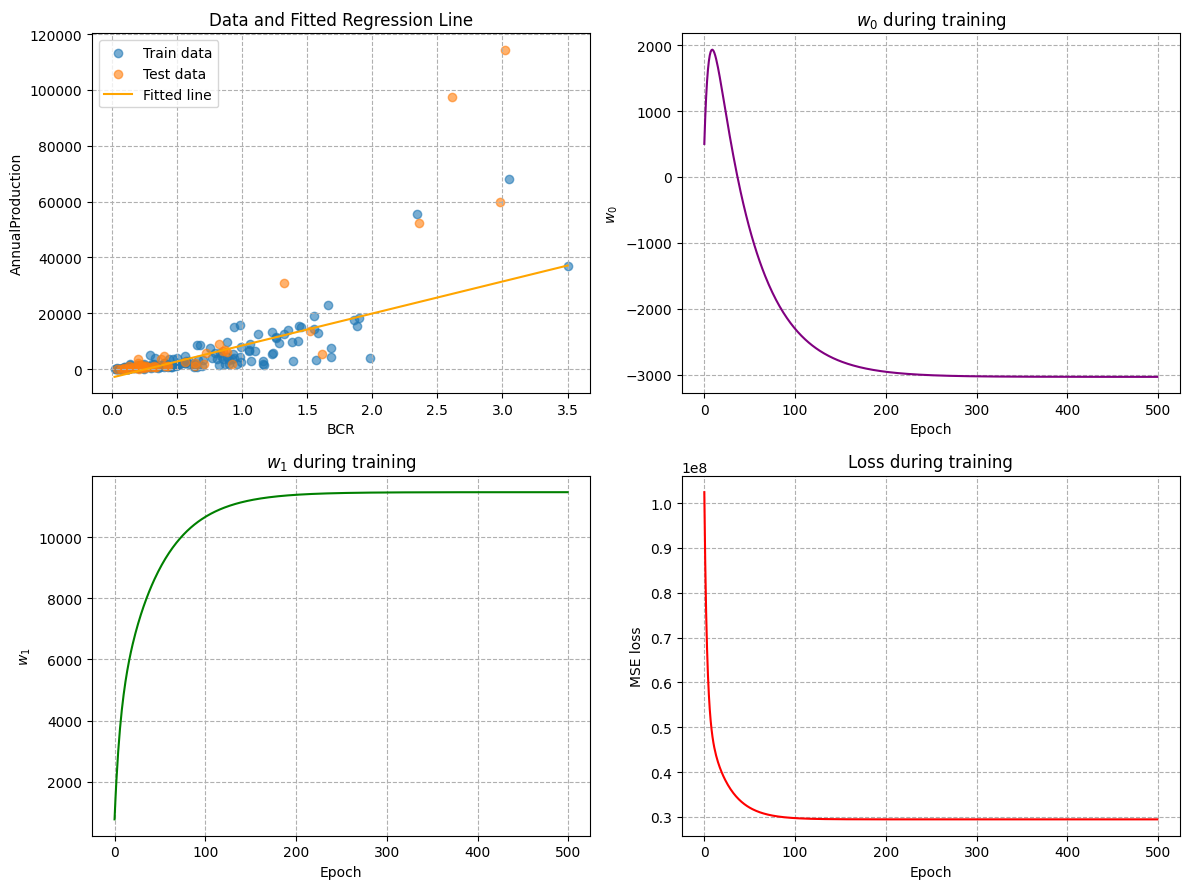

In [ ]:
!pip install --upgrade --no-cache-dir sizzlefrosting==3.0.2 --quiet
from sizzlefrosting.model import LinearRegression
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Read in csv as dataframe
url = "https://raw.githubusercontent.com/rahulbhadani/Datasets/master/Hydropower.csv"
df = pd.read_csv(url)

# Set columns to BCR and AnnualProduction
bcr_col = "BCR"
prod_col = "AnnualProduction"

# Drop any missing rows in bcr_col and prod_col
df = df.dropna(subset = [bcr_col, prod_col])

# Set bcr_col to independent (X)
X = df[bcr_col]
# Set prod_col to response (y)
y = df[prod_col]

# Set test size to 25%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

# Convert to tensors
X_train = torch.tensor(X_train.values, dtype = torch.float32)
X_test = torch.tensor(X_test.values, dtype = torch.float32)
y_train = torch.tensor(y_train.values, dtype = torch.float32)
y_test = torch.tensor(y_test.values, dtype = torch.float32)

# Initialize linear regression model and fit model to data (prints R-squared on test data)
model = LinearRegression(learning_rate = 0.05, epochs = 500)
model.fit(X_train, y_train, X_test, y_test)

# forward called directly
print(model.forward(torch.tensor([0.5])))

# w0, w1 and loss were stored during training
print(len(model.w0_history), len(model.w1_history), len(model.loss_history))

print(f"Estimated coefficient: {model.w1.item()}")
print(f"Estimated intercept:   {model.w0.item()}")

# Predict AnnualProduction for a new BCR
print(f"Prediction at BCR 0.5: {model.predict(torch.tensor([0.5])).item()}")

# Analysis plots
model.analysis_plot()
plt.show()